### ROD CUTTING

In [65]:
import time
import matplotlib.pyplot as plt

### Recursive

In [66]:
def rc1(n, prices):
    if n <= 0:
        return [[], 0]
    maxVal = -1
    maxList = []
    for i in range(n):
        val = rc1(n - i - 1, prices)
        maxVal = max(maxVal, prices[i] + val[1])
        if (maxVal == prices[i] + val[1]):
            maxList = val[0] + [i + 1]
    return [maxList, maxVal]

### Memoization

In [67]:
def rc2(n, prices, dp):
    if n <= 0:
        return [[], 0]
    
    if dp[n][1] != -1:
        return dp[n]
    
    maxVal = -1
    maxList = []
    for i in range(n):
        val = rc2(n - i - 1, prices, dp)
        maxVal = max(maxVal, prices[i] + val[1])
        if (maxVal == prices[i] + val[1]):
            maxList = val[0] + [i + 1]
    dp[n] = [maxList, maxVal]
    return dp[n]

### Tabulation

In [68]:
def rc3(n, prices, dp):
    dp[0] = [[], 0]
    for i in range(1, n + 1):
        maxVal = -1
        maxList = []
        for j in range(i):
            val = dp[i - j - 1]
            maxVal = max(maxVal, prices[j] + val[1])
            if (maxVal == prices[j] + val[1]):
                maxList = val[0] + [j + 1]
        dp[i] = [maxList, maxVal]
    return dp[n]

### Using The Functions

In [69]:
n = int(input('Enter the length of the rod: '))
prices = list(map(int, input('Enter the prices: ').split()))

print('Using Recursive Approach . . .')
start = time.perf_counter_ns()
result = rc1(n, prices)
end = time.perf_counter_ns()
t1 = end - start
print(f'Maximum profit = {result[1]} for partition = {result[0]} and time taken is {t1} ns\n')

dp = [[[], -1]] * (n + 1)
print('Using Memoization . . .')
start = time.perf_counter_ns()
result = rc2(n, prices, dp)
end = time.perf_counter_ns()
t2 = end - start
print(f'Maximum profit = {result[1]} for partition = {result[0]} and time taken is {t2} ns\n')

dp = [[[], 0]] * (n + 1)
print('Using Tabulation . . .')
start = time.perf_counter_ns()
result = rc3(n, prices, dp)
end = time.perf_counter_ns()
t3 = end - start
print(f'Maximum profit = {result[1]} for partition = {result[0]} and time taken is {t3} ns\n')

Using Recursive Approach . . .
Maximum profit = 22 for partition = [2, 6] and time taken is 85708 ns

Using Memoization . . .
Maximum profit = 22 for partition = [2, 6] and time taken is 27875 ns

Using Tabulation . . .
Maximum profit = 22 for partition = [2, 6] and time taken is 27833 ns



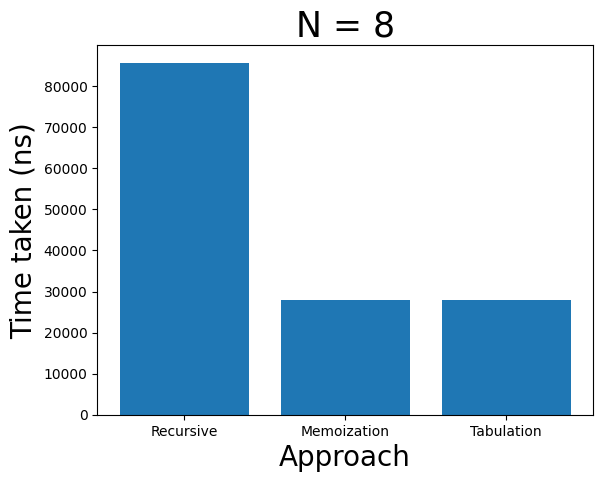

In [70]:
plt.bar(['Recursive', 'Memoization', 'Tabulation'], [t1, t2, t3])
plt.xlabel('Approach', fontsize = 20)
plt.ylabel('Time taken (ns)', fontsize = 20)
plt.title(f'N = {n}', fontsize = 25)
plt.show()